In [4]:
import numpy as np
import pennylane as qml

In [ ]:
# queremos encontrar o estado |11> 

n_qubits = 3 

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def grover_2qubits():
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    #oracle p/ encontrar |11> 
    qml.Toffoli(wires=[0,1,2])

    #difusor 
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
        qml.PauliX(wires=q)
    
    qml.CZ(wires=[0,1])

    for q in range(n_qubits - 1):
        qml.PauliX(wires=q)
        qml.Hadamard(wires=q)
    
    return qml.probs(wires=[0,1])
    






(<Figure size 1100x400 with 1 Axes>, <Axes: >)

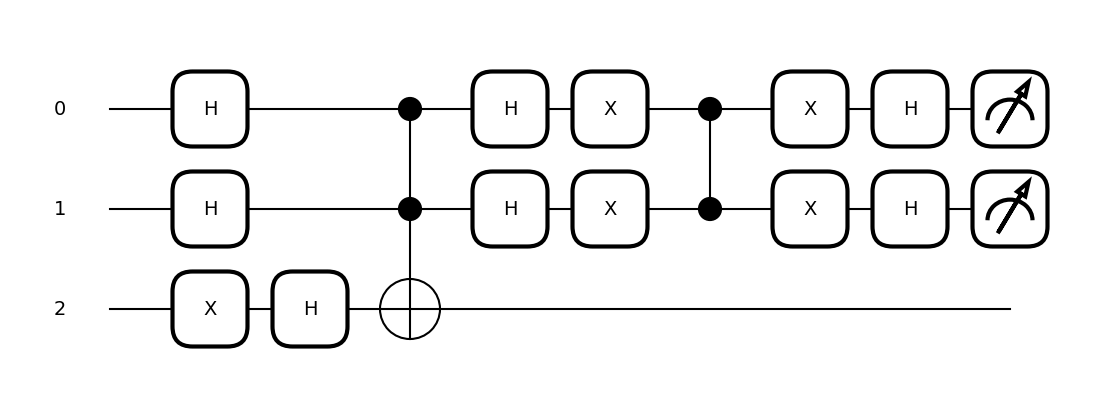

In [11]:
qml.draw_mpl(grover_2qubits)()

In [10]:
grover_2qubits()

array([0., 0., 0., 1.])

In [41]:
# queremos encontrar o estado |11> 

n_qubits = 3 

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def grover_2qubits(iterations):
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    for j in range(iterations):
        #oracle p/ encontrar |111> 
        qml.ctrl(qml.PauliX , range(n_qubits-1))(n_qubits-1) 

        #difusor 
        for q in range(n_qubits - 1):
            qml.Hadamard(wires=q)
            qml.PauliX(wires=q)
        
        qml.ctrl(qml.PauliZ , range(n_qubits-2))(n_qubits-2) 

        for q in range(n_qubits - 1):
            qml.PauliX(wires=q)
            qml.Hadamard(wires=q)
    
    return qml.probs(wires=range(n_qubits-1))
    






(<Figure size 1700x400 with 1 Axes>, <Axes: >)

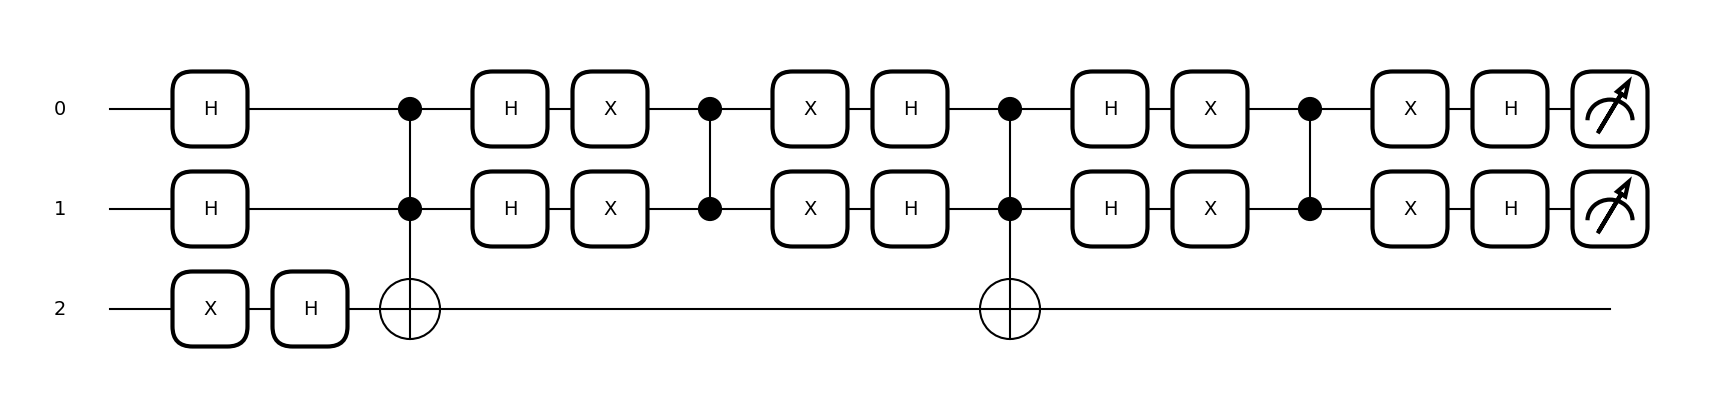

In [45]:

iterations = 2
qml.draw_mpl(grover_2qubits)(iterations)

In [46]:
grover_2qubits(iterations)

array([0.25, 0.25, 0.25, 0.25])